In [1]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, models
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image
import os

In [2]:
SEED = 69
ENABLE_DETERMINISM = True

import os
os.environ['PYTHONHASHSEED'] = f'{SEED}'
os.environ['TF_DETERMINISTIC_OPS'] = f'{ENABLE_DETERMINISM}'
os.environ['TF_CUDNN_DETERMINISTIC'] = f'{ENABLE_DETERMINISM}'

import random
import numpy as np
import tensorflow as tf
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

In [ ]:
!pip install -q kaggle
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

In [ ]:
#!/bin/bash
!kaggle datasets download sharmajhalak/trashnet

Dataset URL: https://www.kaggle.com/datasets/sharmajhalak/trashnet
License(s): unknown
  0% 0.00/19.9M [00:00<?, ?B/s]
100% 19.9M/19.9M [00:00<00:00, 1.21GB/s]


In [ ]:
import zipfile

with zipfile.ZipFile("/content/trashnet.zip", 'r') as zip_ref:
    zip_ref.extractall("/content/trash")

In [ ]:
train_dir = "/content/trash/train"
test_dir = "/content/trash/valid"

In [ ]:
def oo (data):
  for classes in os.listdir(data):
    class_path = os.path.join(data,classes)
    print(f"calss: {classes}: {len(os.listdir(class_path))}")
print("train")
oo(train_dir)
print("Test")
oo(test_dir)

train
calss: cardboard: 349
calss: glass: 447
calss: plastic: 428
Test
calss: cardboard: 54
calss: glass: 54
calss: plastic: 54


In [ ]:
def check_image_sizes(data_dir):
    sizes = []

    for cls in os.listdir(data_dir):
        cls_path = os.path.join(data_dir, cls)

        images = os.listdir(cls_path)
        sample_images = random.sample(images,len(images))

        for img_name in sample_images:
            img_path = os.path.join(cls_path, img_name)

            try:
                with Image.open(img_path) as img:
                  sizes.append(img.size)
            except:
                pass
    return sizes
unique = set(check_image_sizes(train_dir))
print(unique)
unique = set(check_image_sizes(test_dir))
print(unique)

{(512, 384)}
{(512, 384)}


In [ ]:
def check_image_modes(data_dir):
    modes = set()

    for cls in os.listdir(data_dir):
        cls_path = os.path.join(data_dir, cls)
        images = os.listdir(cls_path)

        for img_name in images:
            img_path = os.path.join(cls_path, img_name)

            try:
                with Image.open(img_path) as img:
                    modes.add(img.mode)
            except:
                pass
    return modes

modes = check_image_modes(train_dir)
print("Image Modes:", modes)
modes = check_image_modes(test_dir)
print("Image Modes:", modes)

Image Modes: {'RGB'}
Image Modes: {'RGB'}


In [ ]:
def check_formats(data_dir):
    formats = set()

    for cls in os.listdir(data_dir):
        cls_path = os.path.join(data_dir, cls)

        for img_name in os.listdir(cls_path):
            ext = os.path.splitext(img_name)[1]
            formats.add(ext.lower())

    return formats

formats = check_formats(train_dir)
print("Image Formats:", formats)

formats = check_formats(test_dir)
print("Image Formats:", formats)

Image Formats: {'.jpg'}
Image Formats: {'.jpg'}


In [ ]:
def find_corrupted_images(data_dir):
    corrupted = []

    for cls in os.listdir(data_dir):
        cls_path = os.path.join(data_dir, cls)

        for img_name in os.listdir(cls_path):
            img_path = os.path.join(cls_path, img_name)

            try:
                with Image.open(img_path) as img:
                    img.verify()
            except:
                corrupted.append(img_path)

    return corrupted

corrupted_images = find_corrupted_images(train_dir)
print("Number of corrupted images:", len(corrupted_images))

Number of corrupted images: 0


In [ ]:
# def resize(data_dir):

#     for cls in os.listdir(data_dir):
#         cls_path = os.path.join(data_dir, cls)
#         images = os.listdir(cls_path)

#         for img_name in images:
#             img_path = os.path.join(cls_path, img_name)
#             try:
#                 with Image.open(img_path) as img:
#                     img_resized = img.resize((256, 256))
#                     img_resized.save(img_path)

#             except:
#                 pass
# resize(train_dir)
# resize(test_dir)
# sizes = check_image_sizes(train_dir)
# unique_sizes = set(sizes)

# print("Unique image sizes found:")
# print(unique_sizes)

In [ ]:
IMG_SIZE = (512//2,384//2)

train_ds = tf.keras.utils.image_dataset_from_directory(
    train_dir,
    validation_split=0.2,
    subset="training",
    seed=42,
    image_size=IMG_SIZE,
    shuffle = True
)

val_ds = tf.keras.utils.image_dataset_from_directory(
    train_dir,
    validation_split=0.2,
    subset="validation",
    seed=42,
    image_size=IMG_SIZE,
    shuffle = True


)

test_ds = tf.keras.utils.image_dataset_from_directory(
    test_dir,
    image_size=IMG_SIZE,
)

Found 1224 files belonging to 3 classes.
Using 980 files for training.
Found 1224 files belonging to 3 classes.
Using 244 files for validation.
Found 162 files belonging to 3 classes.


In [ ]:
data_augmentation = keras.Sequential([
    layers.RandomFlip("horizontal"),
    #layers.RandomRotation(0.1),
    # layers.RandomZoom(0.1),
])

In [ ]:
def build_model(input_shape=(512//2,384//2, 3), num_classes=3):

    inputs = layers.Input(shape=input_shape)

    # augmentation
    x = data_augmentation(inputs)

    # Normalize pixels
    x = layers.Rescaling(1./255)(x)

    # CNN
    x = layers.Conv2D(64, (3,3), padding='same')(x)
    x = layers.BatchNormalization()(x)
    x = layers.ReLU()(x)
    x = layers.MaxPooling2D()(x)

    x = layers.Conv2D(128, (3,3), padding='same')(x)
    x = layers.BatchNormalization()(x)
    x = layers.ReLU()(x)
    x = layers.Conv2D(256, (3,3), padding='same')(x)
    x = layers.BatchNormalization()(x)
    x = layers.ReLU()(x)
    x = layers.MaxPooling2D()(x)

    # x = layers.Conv2D(64, (3,3), padding='same')(x)
    # x = layers.BatchNormalization()(x)
    # x = layers.ReLU()(x)
    # x = layers.Conv2D(64, (3,3), padding='same')(x)
    # x = layers.BatchNormalization()(x)
    # x = layers.ReLU()(x)
    # x = layers.MaxPooling2D()(x)

    # x = layers.Conv2D(256, (3,3), padding='same')(x)
    # x = layers.BatchNormalization()(x)
    # x = layers.ReLU()(x)
    # x = layers.MaxPooling2D()(x)

    x = layers.GlobalMaxPooling2D()(x)

    # x = layers.Dense(500)(x)
    # x = layers.ReLU()(x)

    #x = layers.Dropout(0.1)(x)

    outputs = layers.Dense(num_classes, activation='softmax')(x)

    model = models.Model(inputs, outputs)
    return model


model = build_model(num_classes=3)
model.summary()

Model: "functional_13"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_14 (InputLayer)     │ (None, 256, 192, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ sequential_4 (Sequential)       │ (None, 256, 192, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescaling_9 (Rescaling)         │ (None, 256, 192, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_34 (Conv2D)              │ (None, 256, 192, 64)   │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_34          │ (None, 256, 192, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_34 (ReLU)                 │ (None, 256, 192, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_19 (MaxPooling2D) │ (None, 128, 96, 64)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_35 (Conv2D)              │ (None, 128, 96, 128)   │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_35          │ (None, 128, 96, 128)   │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_35 (ReLU)                 │ (None, 128, 96, 128)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_36 (Conv2D)              │ (None, 128, 96, 256)   │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_36          │ (None, 128, 96, 256)   │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_36 (ReLU)                 │ (None, 128, 96, 256)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_20 (MaxPooling2D) │ (None, 64, 48, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_max_pooling2d_9          │ (None, 256)            │             0 │
│ (GlobalMaxPooling2D)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 3)              │           771 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 373,379 (1.42 MB)

 Trainable params: 372,483 (1.42 MB)

 Non-trainable params: 896 (3.50 KB)

In [ ]:
from tensorflow.keras.optimizers import Adam

model.compile(
    optimizer=Adam(learning_rate=1e-2),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

In [ ]:
callbacks = [
    tf.keras.callbacks.EarlyStopping(
        patience=10,
        restore_best_weights=True
    ),
    tf.keras.callbacks.ReduceLROnPlateau(
        factor=0.5,
        patience=5
    )
]

In [ ]:
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=100,
    callbacks=callbacks
)

Epoch 1/100
31/31 ━━━━━━━━━━━━━━━━━━━━ 15s 413ms/step - accuracy: 0.4316 - loss: 2.5489 - val_accuracy: 0.2582 - val_loss: 18.2145 - learning_rate: 0.0100
Epoch 2/100
31/31 ━━━━━━━━━━━━━━━━━━━━ 13s 425ms/step - accuracy: 0.5337 - loss: 0.9989 - val_accuracy: 0.2951 - val_loss: 5.0006 - learning_rate: 0.0100
Epoch 3/100
31/31 ━━━━━━━━━━━━━━━━━━━━ 14s 443ms/step - accuracy: 0.5949 - loss: 0.9056 - val_accuracy: 0.4344 - val_loss: 2.1581 - learning_rate: 0.0100
Epoch 4/100
31/31 ━━━━━━━━━━━━━━━━━━━━ 13s 429ms/step - accuracy: 0.6143 - loss: 0.8266 - val_accuracy: 0.4754 - val_loss: 1.1002 - learning_rate: 0.0100
Epoch 5/100
31/31 ━━━━━━━━━━━━━━━━━━━━ 13s 416ms/step - accuracy: 0.6102 - loss: 0.9204 - val_accuracy: 0.5369 - val_loss: 0.9514 - learning_rate: 0.0100
Epoch 6/100
31/31 ━━━━━━━━━━━━━━━━━━━━ 13s 412ms/step - accuracy: 0.6806 - loss: 0.7494 - val_accuracy: 0.5779 - val_loss: 0.9032 - learning_rate: 0.0100
Epoch 7/100
31/31 ━━━━━━━━━━━━━━━━━━━━ 13s 413ms/step - accuracy: 0.6245 - 

In [ ]:
test_loss, test_acc = model.evaluate(test_ds)

print("Test Accuracy:", test_acc)

6/6 ━━━━━━━━━━━━━━━━━━━━ 1s 80ms/step - accuracy: 0.9074 - loss: 0.2601
Test Accuracy: 0.9074074029922485


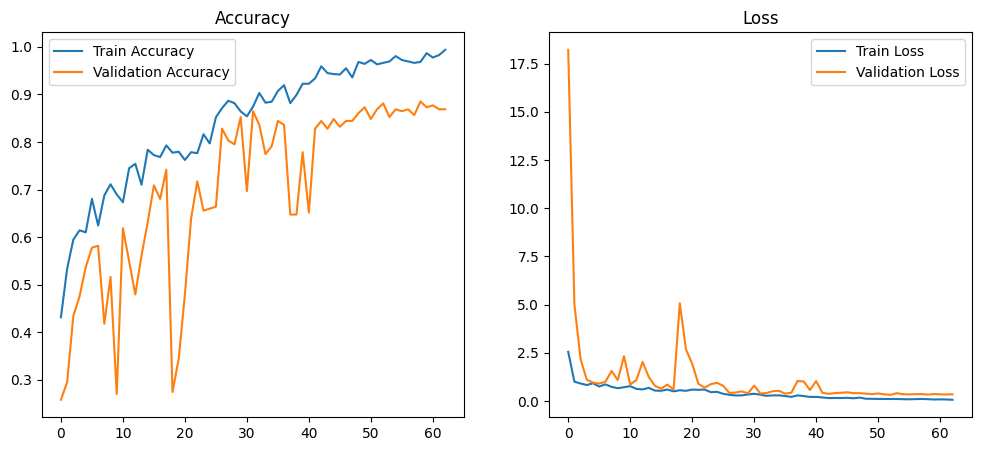

In [ ]:

acc = history.history["accuracy"]
val_acc = history.history["val_accuracy"]

loss = history.history["loss"]
val_loss = history.history["val_loss"]

plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.plot(acc,label="Train Accuracy")
plt.plot(val_acc,label="Validation Accuracy")
plt.legend()
plt.title("Accuracy")

plt.subplot(1,2,2)
plt.plot(loss,label="Train Loss")
plt.plot(val_loss,label="Validation Loss")
plt.legend()
plt.title("Loss")

plt.show()